# CW-ODMR spectrum scan

Plots the result of `python cw_odmr.py run_spectrum <name>` (`cmd_run_spectrum()`) --
instead of one long acquisition at a fixed resonance frequency, it steps across the
resonance's FWHM at a fixed drive power, capturing a handful of scope segments at each
frequency. Currently the scope's Channel 1 signal is a dummy AWG carrier standing in for
the real laser/PL signal (see cw_odmr.py's `setup_awg()`), so "fluorescence" here is really
just the average signal voltage, the same proxy metric used throughout `analyze_data.ipynb`
-- not a real photoluminescence reading yet. No live instrument connection needed here --
everything comes from the saved `.npy`/metadata files.

Each trial scans a different frequency window (see the table below). Trials with a saved
`run_background` (`_bg.npy`) acquisition also get a background-subtracted comparison.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "D:/cw_odmr"

# name -> (freqs_hz step used, has its own run_background _bg.npy acquisition)
TRIAL_NAMES = ["trial1", "trial1_again", "trial2", "trial3", "trial4", "trial5"]

## Load all trials

For each trial: load the spectrum + frequency axis, compute the per-frequency average
voltage and SEM (averaging over samples within a segment, then over segments), and load
its background acquisition if one was saved.

In [2]:
def load_trial(name):
    run_path = f"{DATA_DIR}/{name}"
    spectrum = np.load(f"{run_path}/{name}_spectrum.npy")
    freqs_hz = np.load(f"{run_path}/{name}_spectrum_freqs_hz.npy")

    seg_means = spectrum.mean(axis=2)  # (freq_points, segments_per_point)
    avg_voltage = seg_means.mean(axis=1)
    sem_voltage = seg_means.std(axis=1) / np.sqrt(seg_means.shape[1])

    trial = {
        "name": name,
        "freqs_ghz": freqs_hz / 1e9,
        "avg_voltage": avg_voltage,
        "sem_voltage": sem_voltage,
        "step_khz": (freqs_hz[1] - freqs_hz[0]) / 1e3,
        "segments_per_point": spectrum.shape[1],
    }

    bg_path = f"{run_path}/{name}_bg.npy"
    if os.path.exists(bg_path):
        bg_seg_mean = np.load(bg_path).mean(axis=-1)
        bg_mean = bg_seg_mean.mean()
        bg_sem = bg_seg_mean.std() / np.sqrt(len(bg_seg_mean))
        trial["bg_mean"] = bg_mean
        trial["bg_sem"] = bg_sem
        trial["net_voltage"] = avg_voltage - bg_mean
        trial["net_err"] = np.sqrt(sem_voltage**2 + bg_sem**2)

    return trial

import os
trials = [load_trial(name) for name in TRIAL_NAMES]

for t in trials:
    has_bg = "bg_mean" in t
    print(f"{t['name']}: {t['freqs_ghz'].min():.6f}-{t['freqs_ghz'].max():.6f} GHz "
          f"({t['step_khz']:.1f} kHz step, {t['segments_per_point']} segments/point), "
          f"voltage {t['avg_voltage'].min():.5f} to {t['avg_voltage'].max():.5f} V"
          + (f", background = {t['bg_mean']:.5f} +/- {t['bg_sem']:.6f} V" if has_bg else 
             ", no background acquisition"))

trial1: 2.850875-2.863375 GHz (100.0 kHz step, 10 segments/point), voltage -0.01371 to -0.00777 V, background = -0.01025 +/- 0.000142 V
trial1_again: 2.849475-2.863475 GHz (1000.0 kHz step, 10 segments/point), voltage -0.01382 to -0.01000 V, no background acquisition
trial2: 2.878050-2.889150 GHz (100.0 kHz step, 20 segments/point), voltage -0.01585 to -0.01140 V, background = -0.01419 +/- 0.000160 V
trial3: 2.860675-2.873975 GHz (100.0 kHz step, 20 segments/point), voltage -0.01460 to -0.01043 V, background = -0.01265 +/- 0.000159 V
trial4: 2.865075-2.877175 GHz (100.0 kHz step, 20 segments/point), voltage -0.01500 to -0.01105 V, background = -0.01264 +/- 0.000144 V
trial5: 2.879475-2.892675 GHz (100.0 kHz step, 20 segments/point), voltage -0.01527 to -0.01136 V, background = -0.01441 +/- 0.000170 V


## Average signal voltage vs. frequency (all trials)

Each trial scans a different frequency window at a fixed drive power; plotted together on
one frequency axis. Error bars are the SEM across the `segments_per_point` segments
captured at each frequency point.

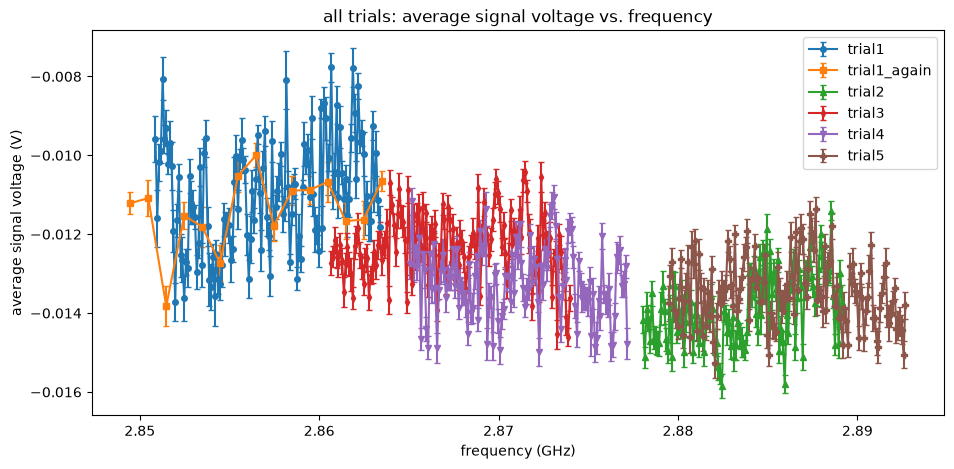

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

markers = ["o", "s", "^", "d", "v", "P", "X", "*"]
for i, t in enumerate(trials):
    ax.errorbar(t["freqs_ghz"], t["avg_voltage"], yerr=t["sem_voltage"],
                fmt=markers[i % len(markers)] + "-", ms=4, capsize=2,
                color=f"C{i}", label=t["name"])

ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("average signal voltage (V)")
ax.set_title("all trials: average signal voltage vs. frequency")
ax.legend()
plt.show()

## Reflected power vs. frequency (sanity check, trial1)

The per-point reflected-power reading used for the inline interlock check during the scan
-- should trace out the resonance's reflection dip shape across the scanned span, as a
sanity check that the scan actually covered the resonance.

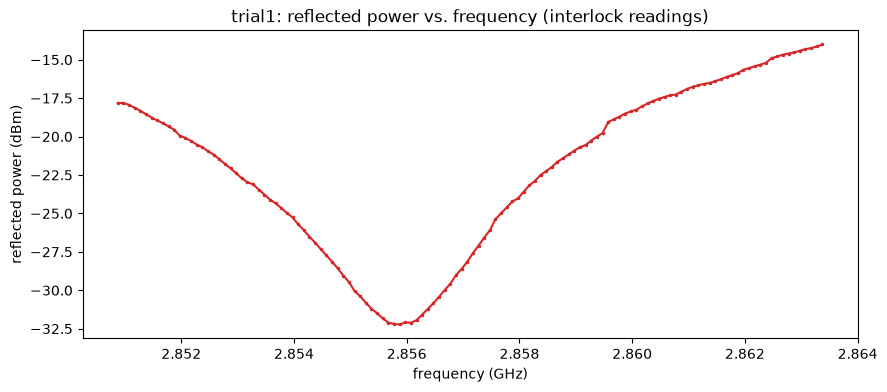

In [4]:
reflected_dbm = np.load(f"{DATA_DIR}/trial1/trial1_spectrum_reflected_dbm.npy")
freqs_ghz_trial1 = trials[0]["freqs_ghz"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs_ghz_trial1, reflected_dbm, ".-", ms=3, color="C3")
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("reflected power (dBm)")
ax.set_title("trial1: reflected power vs. frequency (interlock readings)")
plt.show()

## Background-subtracted spectra (all trials with a saved background)

Trials with a saved RF-off `_bg.npy` acquisition (from `run_background`) have their own
background segment mean subtracted off, same convention as the background-subtracted
plots in `analyze_data.ipynb`. Error bars are the per-point segment SEM and the
background SEM combined in quadrature. Trials without a saved background (e.g.
`trial1_again`) are excluded here.

trial1_again: no background acquisition -- skipping


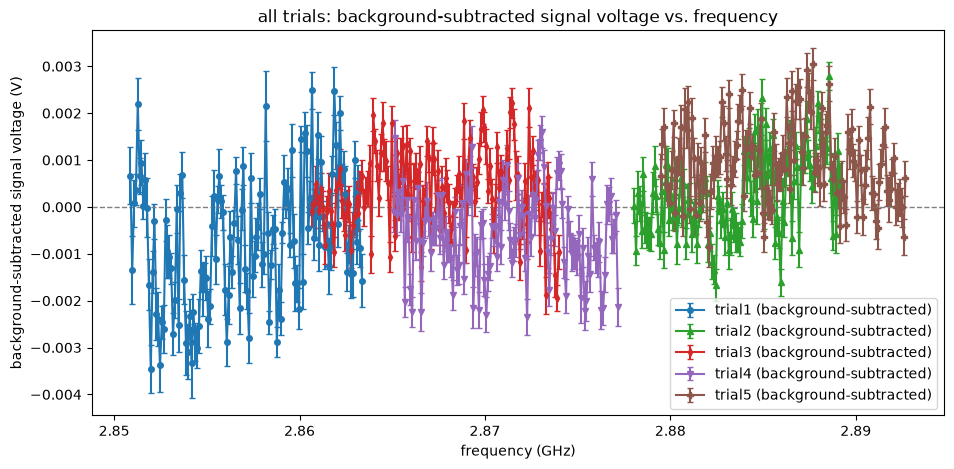

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

for i, t in enumerate(trials):
    if "net_voltage" not in t:
        print(f"{t['name']}: no background acquisition -- skipping")
        continue
    ax.errorbar(t["freqs_ghz"], t["net_voltage"], yerr=t["net_err"],
                fmt=markers[i % len(markers)] + "-", ms=4, capsize=2,
                color=f"C{i}", label=f"{t['name']} (background-subtracted)")

ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("background-subtracted signal voltage (V)")
ax.set_title("all trials: background-subtracted signal voltage vs. frequency")
ax.legend()
plt.show()

## `trial6` resonance (fine sweep)

`trial6` only has the resonance-finding sweep saved so far (no `run_spectrum` data yet).
Same depth/FWHM/Q methodology as `cw_odmr.py`'s `resonance_sweep()` -- `HP8673H.estimate_q()` is a `@staticmethod`, so it runs directly on the saved fine-sweep CSV with no instrument connection, same as `analyze_data.ipynb`.

trial6: f0 = 2.04380 GHz
trial6: dip = -52.99 dBm, baseline = -49.96 dBm
trial6: depth = 3.03 dB
trial6: FWHM = 6.600 MHz, Q ~= 310


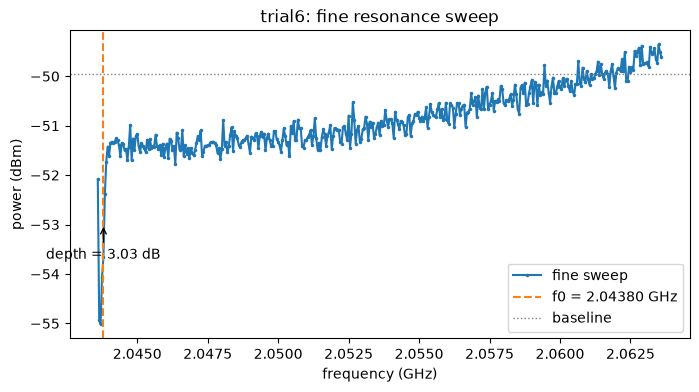

In [6]:
from hp8673h import HP8673H

trial6_fine = np.genfromtxt(f"{DATA_DIR}/trial6/trial6_resonance_fine.csv",
                             delimiter=",", names=True)
trial6_result = HP8673H.estimate_q(trial6_fine["frequency_hz"], trial6_fine["power_dbm"])
trial6_depth_db = trial6_result["baseline_dbm"] - trial6_result["dip_dbm"]

print(f"trial6: f0 = {trial6_result['f0_hz']/1e9:.5f} GHz")
print(f"trial6: dip = {trial6_result['dip_dbm']:.2f} dBm, baseline = {trial6_result['baseline_dbm']:.2f} dBm")
print(f"trial6: depth = {trial6_depth_db:.2f} dB")
print(f"trial6: FWHM = {trial6_result['fwhm_hz']/1e6:.3f} MHz, Q ~= {trial6_result['Q']:.0f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(trial6_fine["frequency_hz"] / 1e9, trial6_fine["power_dbm"], ".-", ms=3, label="fine sweep")
ax.axvline(trial6_result["f0_hz"] / 1e9, color="C1", ls="--",
           label=f"f0 = {trial6_result['f0_hz']/1e9:.5f} GHz")
ax.axhline(trial6_result["baseline_dbm"], color="gray", ls=":", lw=1, label="baseline")
ax.annotate(
    f"depth = {trial6_depth_db:.2f} dB",
    xy=(trial6_result["f0_hz"] / 1e9, trial6_result["dip_dbm"]),
    xytext=(0, -25), textcoords="offset points",
    ha="center", arrowprops=dict(arrowstyle="->"),
)
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("power (dBm)")
ax.set_title("trial6: fine resonance sweep")
ax.legend()
plt.show()

## `trial6` resonance (coarse sweep)

The coarse sweep that located the dip before the fine sweep zoomed in around it.

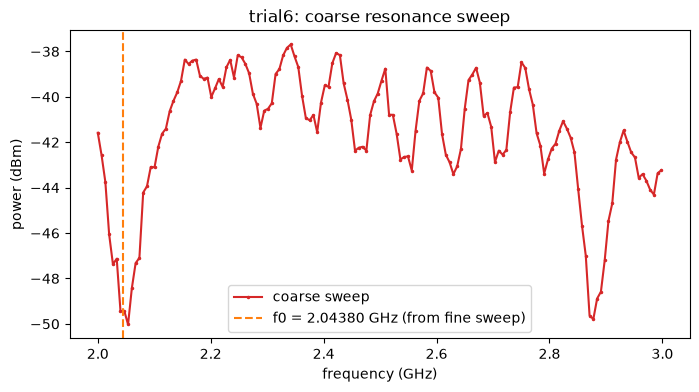

In [7]:
trial6_coarse = np.genfromtxt(f"{DATA_DIR}/trial6/trial6_resonance_coarse.csv",
                               delimiter=",", names=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(trial6_coarse["frequency_hz"] / 1e9, trial6_coarse["power_dbm"], ".-", ms=3,
        color="C3", label="coarse sweep")
ax.axvline(trial6_result["f0_hz"] / 1e9, color="C1", ls="--",
           label=f"f0 = {trial6_result['f0_hz']/1e9:.5f} GHz (from fine sweep)")
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("power (dBm)")
ax.set_title("trial6: coarse resonance sweep")
ax.legend()
plt.show()